<a href="https://colab.research.google.com/github/mariajosemuskusl/Integracion-de-Datos-y-Prospectiva/blob/main/Reto_3_Integraci%C3%B3n_Multidimensional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Reto 3**

**Integración Multidimensional | FINTECH**


---

María José Muskus Londoño

**Objetivo**

Una entidad del sector Fintech requiere reducir el número de sucursales en las cuales atiende a cada uno de sus solicitantes de crédito, para lo cual la entidad financiera quiere llevar a cabo un proceso de integración multidimensional de los datos a cinco sucursales.

**Abstracción**

Las variables utilizadas para esta integración se basan principalmente en las siguientes variables numéricas:
- Edad
- Hijos
- Personas a cargo
- Estrato
- Ingresos
- Egresos
- Monto
- Plazo
- Cuota del crédito

Es importante determinar para cada una de las nuevas sucursales el número de clientes, los municipios de donde proceden cada uno de los solicitantes de crédito y cual es el porcentaje de preaprobación o prenegación.

**Métodos**

- Para la integración multidimensional se sugiere el método K-Medodis, tomando como referencia un total de 5 semillas aleatorias que, pueden ser los primeros cinco solicitantes de crédito.
- Representar los clusters mendiante la utilización de gráficos de araña o cualquier otra gráfica que permita la representación de datos multidimensionales.
- Desplegar los resultados en una página web a la plataforma GitHub con el fin de ayudar a la empresa a la toma de decisiones.

**0. Librerías de trabajo**


In [116]:
# Importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conexión con drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1. Carga y revisión inicial de la base de datos**

In [117]:
# Cargo el archivo de Excel con la base de solicitantes
df = pd.read_excel("/content/drive/MyDrive/University/Integración de Datos y Prospectiva/Retos/Reto 3/4. SolicitantesCrédito(USD)_Municipios.xlsx")

# Desordeno aleatoriamente los datos para eliminar cualquier sesgo de orden
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Elimino posibles registros con datos faltantes
df = df.dropna()

# Reviso el tamaño de la base de datos para confirmar cuántos registros y columnas tengo
print("Dimensión de la base de datos:", df.shape)

# Muestro las primeras filas
df.head()

Dimensión de la base de datos: (5842, 38)


,Cédula,Edad,Sexo,Estado civil,Hijos,Perscargo,Nivel Renta,Estrato,Nivel de estudios,Tipo de contrato,...,ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD,Net_Income,Municipio
0,6556,63,NR,Unión Libre,1,1,1,3,Bachiller,Ninguno,...,Buenas Referencias,Fondo de Garantia,Sin Patrimonio,Con Experiencia sin Mora,0,0.233305,474.284668,0.473965,94.814667,Caldas
1,239,31,Mujer,Soltero,0,1,1,2,Tecnólogo,Indefinido,...,Buena Experiencia CFB,Fondo de Garantia,Prop.sin Hipoteca,Con Experiencia sin Mora,0,0.254857,322.984283,0.386951,-59.363306,Caldas
2,226,61,NR,Casado,7,3,3,2,Tecnólogo,Indefinido,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.089151,619.955383,0.156131,175.430444,Sabaneta
3,8017,42,Mujer,Soltero,2,1,1,3,Tecnólogo,Fijo,...,Buena Experiencia CFB,Libranza Establecida,Sin Patrimonio,Una mora 60 Dìas,0,0.157716,486.018250,0.292610,265.696222,Caldas
4,3334,32,Mujer,Soltero,1,1,1,4,Bachiller,Indefinido,...,Buenas Referencias,Fondo de Garantia,Sin Patrimonio,Con Experiencia sin Mora,0,0.089574,517.180481,0.155736,406.870611,Itagüí


In [118]:
# Variables que voy a usar para la integración
variables = ['Edad', 'Hijos', 'Perscargo', 'Estrato',
                 'Ingresos', 'Egresos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)']

columnas_necesarias = variables + ['Municipio', 'PreApr']
XDB = df[columnas_necesarias].dropna().reset_index(drop=True)

print('\nVariables utilizadas en el análisis:')
print(XDB.columns.tolist())


Variables utilizadas en el análisis:
['Edad', 'Hijos', 'Perscargo', 'Estrato', 'Ingresos', 'Egresos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)', 'Municipio', 'PreApr']


**2. Descripción de las variables numéricas**

In [119]:
display(XDB[variables].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
Edad,5842.0,41.05,12.23,21.00,31.00,41.00,50.00,73.00
Hijos,5842.0,1.07,1.23,0.00,0.00,1.00,2.00,7.00
Perscargo,5842.0,0.85,1.02,0.00,0.00,1.00,1.00,5.00
Estrato,5842.0,2.91,0.99,1.00,2.00,3.00,3.00,6.00
Ingresos,5842.0,726.81,503.49,1.21,331.42,650.70,1004.66,2994.88
Egresos,5842.0,647.63,507.89,0.56,265.23,532.97,900.87,3141.74
Monto (EAD),5842.0,532.11,444.58,0.90,211.45,421.18,734.78,4075.51
Plazo,5842.0,32.56,12.71,3.00,24.00,36.00,36.00,60.00
Cuota (COP),5842.0,29.93,52.04,0.03,8.36,17.54,32.10,898.30


**3. Definición de la matriz de trabajo y semillas iniciales**



In [120]:
XD = np.array(XDB[variables], dtype=float)
XC = np.array(XDB[variables].iloc[0:5], dtype=float)
nc = np.zeros((len(XD), 1), dtype=int)


df_semillas = pd.DataFrame(XC, columns=variables)
df_semillas.index = [f'Semilla {i+1}' for i in range(5)]
display(df_semillas.round(2))

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Semilla 1,63.0,1.0,1.0,3.0,176.33,81.52,172.44,48.0,5.07
Semilla 2,31.0,0.0,1.0,2.0,315.82,375.18,137.74,36.0,4.98
Semilla 3,61.0,7.0,3.0,2.0,915.55,740.12,723.59,48.0,21.26
Semilla 4,42.0,2.0,1.0,3.0,483.95,218.26,501.96,48.0,14.74
Semilla 5,32.0,1.0,1.0,4.0,817.09,410.22,819.79,36.0,29.64


**4. Integración multidimensional en cinco sucursales**

In [121]:
for k in range(len(XD)):
    x = XD[k, :]

    # Protección frente a divisiones por cero
    XC_aux = np.where(XC == 0, 1e-8, XC)

    # Distancia relativa cuadrática
    dist = np.sum(((XC_aux - x) / XC_aux) ** 2, axis=1)

    # Selección del cluster más cercano
    ganador = int(np.argmin(dist))
    nc[k, 0] = ganador

    # Actualización del centro del cluster ganador
    XC[ganador, :] = (XC[ganador, :] + x) / 2

df_centros = pd.DataFrame(XC, columns=variables, index=[f'Sucursal {i+1}' for i in range(5)])
display(df_centros.round(2))

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 1,27.17,0.15,1.56,2.05,490.90,514.51,333.74,23.14,30.65
Sucursal 2,61.52,0.00,0.00,1.53,37.20,39.86,22.47,29.69,1.04
Sucursal 3,38.18,0.00,0.00,1.92,247.87,195.82,230.16,31.84,9.10
Sucursal 4,45.86,0.00,0.00,3.26,8.97,7.19,4.77,32.05,0.21
Sucursal 5,56.71,0.00,0.00,4.00,50.87,50.78,31.92,35.47,1.18


**5. Tamaño de cada sucursal**

In [122]:
conteo_cluster = []

for j in range(5):
    cantidad = len(np.where(nc[:, 0] == j)[0])
    conteo_cluster.append(cantidad)

df_tamano = pd.DataFrame({
    'Sucursal': [f'Sucursal {i+1}' for i in range(5)],
    'N_Solicitantes': conteo_cluster
})

display(df_tamano)

,Sucursal,N_Solicitantes
0,Sucursal 1,4973
1,Sucursal 2,131
2,Sucursal 3,412
3,Sucursal 4,66
4,Sucursal 5,260


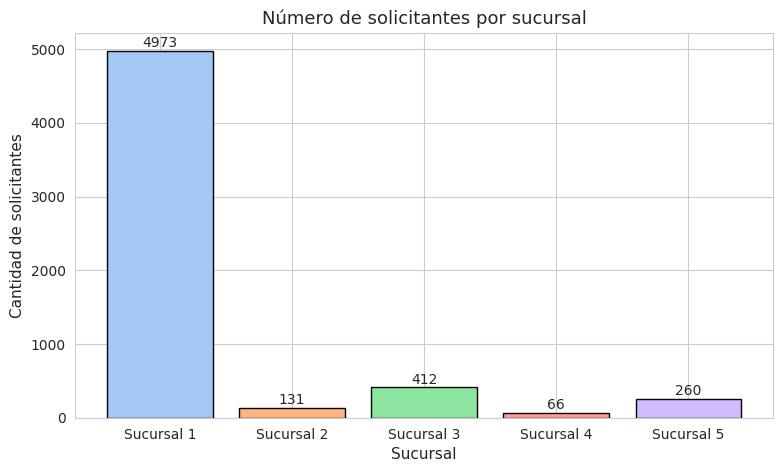

In [123]:
# Gráfico de barras
plt.figure(figsize=(9,5))
bars = plt.bar(df_tamano['Sucursal'], df_tamano['N_Solicitantes'], color=sns.color_palette('pastel', 5), edgecolor='black')
plt.title('Número de solicitantes por sucursal')
plt.xlabel('Sucursal')
plt.ylabel('Cantidad de solicitantes')

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 10, int(y), ha='center', va='bottom')

plt.show()

**6. Construcción del perfil promedio por sucursal**



In [124]:
PRC = np.zeros((5, len(variables)))
XDB_num = XDB[variables]

for j in range(5):
    filas = np.where(nc[:, 0] == j)[0]
    datos_cluster = XDB_num.iloc[filas, :]
    PRC[j, :] = np.mean(datos_cluster, axis=0)

df_perfiles = pd.DataFrame(PRC, columns=variables, index=[f'Sucursal {i+1}' for i in range(5)])
display(df_perfiles.round(2))

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 1,40.99,1.16,0.94,2.92,743.35,660.28,547.07,32.50,31.13
Sucursal 2,41.67,0.00,0.66,2.74,502.42,463.41,336.38,35.36,18.36
Sucursal 3,40.56,1.08,0.45,2.81,565.47,519.22,397.18,33.02,19.97
Sucursal 4,46.52,0.82,0.06,2.88,488.90,439.37,374.10,30.86,18.13
Sucursal 5,41.22,0.02,0.01,3.07,839.60,754.89,598.43,32.10,31.66


**7. Municipios atendidos por cada sucursal**

In [125]:
XDB['Cluster'] = nc[:, 0]
XDB['Sucursal'] = XDB['Cluster'].apply(lambda x: f'Sucursal {x+1}')

tabla_municipios = pd.crosstab(XDB['Municipio'], XDB['Sucursal'])
display(tabla_municipios)

Sucursal,Sucursal 1,Sucursal 2,Sucursal 3,Sucursal 4,Sucursal 5
Municipio,,,,,
Bello,922,14,44,9,58
Caldas,1522,71,192,38,55
Envigado,71,1,2,0,3
Itagüí,491,15,45,9,28
Medellín,395,7,19,3,24
Sabaneta,1572,23,110,7,92


<Figure size 1200x600 with 0 Axes>

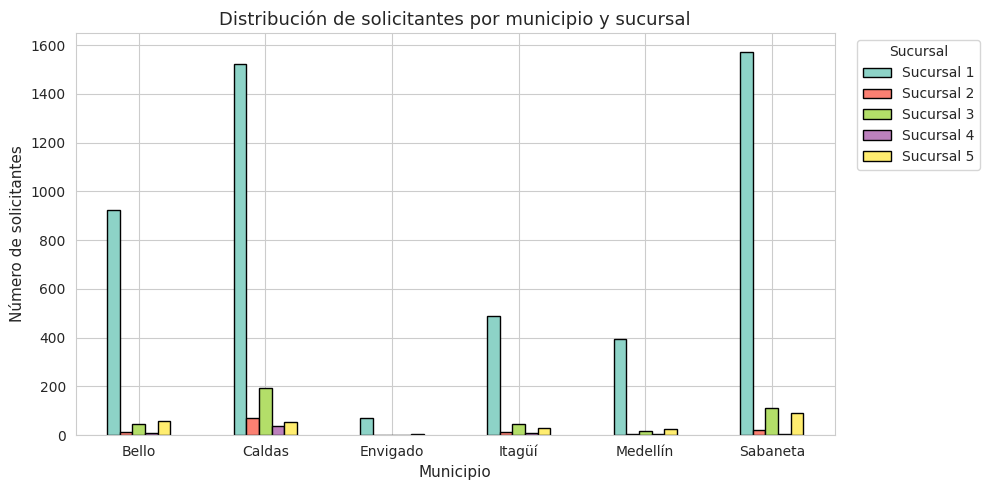

In [126]:
plt.figure(figsize=(12,6))
tabla_municipios.plot(kind='bar', colormap='Set3', edgecolor='black')
plt.title('Distribución de solicitantes por municipio y sucursal')
plt.xlabel('Municipio')
plt.ylabel('Número de solicitantes')
plt.xticks(rotation=0)
plt.legend(title='Sucursal', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [127]:
top_municipios = []

for j in range(5):
    datos_sucursal = XDB[XDB['Sucursal'] == f'Sucursal {j+1}']
    top = datos_sucursal['Municipio'].value_counts().head(3)

    for municipio, cantidad in top.items():
        top_municipios.append({
            'Sucursal': f'Sucursal {j+1}',
            'Municipio': municipio,
            'Cantidad': cantidad
        })

df_top_municipios = pd.DataFrame(top_municipios)
display(df_top_municipios)

,Sucursal,Municipio,Cantidad
0,Sucursal 1,Sabaneta,1572
1,Sucursal 1,Caldas,1522
2,Sucursal 1,Bello,922
3,Sucursal 2,Caldas,71
4,Sucursal 2,Sabaneta,23
5,Sucursal 2,Itagüí,15
6,Sucursal 3,Caldas,192
7,Sucursal 3,Sabaneta,110
8,Sucursal 3,Itagüí,45
9,Sucursal 4,Caldas,38


**8. Preaprobación y prenegación por sucursal**


In [128]:
porc_aprobados = []
porc_negados = []

for j in range(5):
    filas = np.where(nc[:, 0] == j)[0]
    datos_sucursal = XDB.iloc[filas]
    total = len(datos_sucursal)

    aprobados = (datos_sucursal['PreApr'] == 1).sum()
    negados = (datos_sucursal['PreApr'] == 0).sum()

    p_ap = aprobados / total * 100
    p_ng = negados / total * 100

    porc_aprobados.append(p_ap)
    porc_negados.append(p_ng)

df_preapr = pd.DataFrame({
    'Sucursal': [f'Sucursal {i+1}' for i in range(5)],
    'Preaprobacion_%': np.round(porc_aprobados, 2),
    'Prenegacion_%': np.round(porc_negados, 2)
})

display(df_preapr)

,Sucursal,Preaprobacion_%,Prenegacion_%
0,Sucursal 1,50.79,49.21
1,Sucursal 2,32.82,67.18
2,Sucursal 3,36.41,63.59
3,Sucursal 4,31.82,68.18
4,Sucursal 5,55.00,45.00


**9. Comparación gráfica de variables seleccionadas**

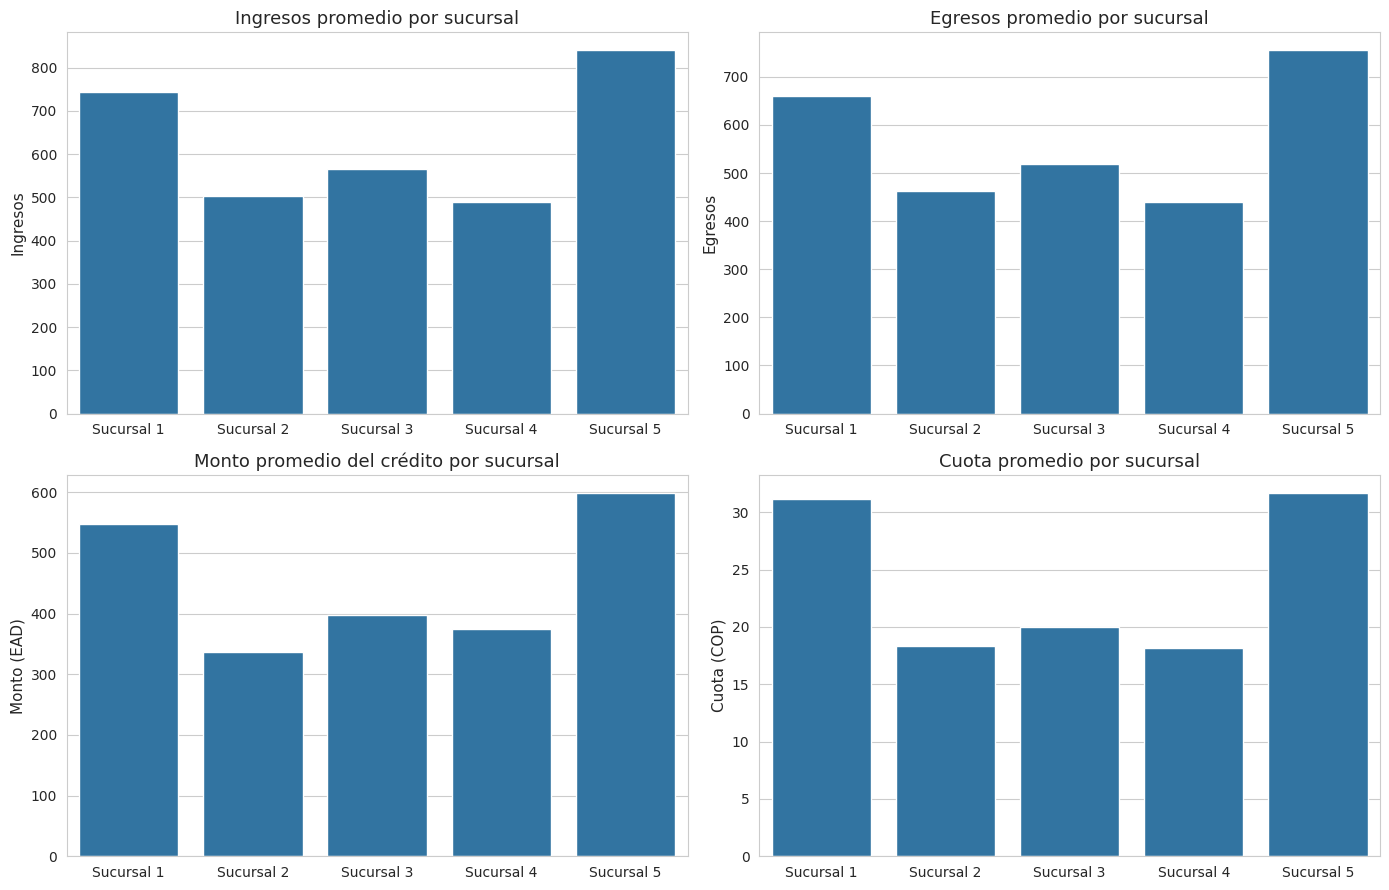

In [130]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.barplot(x=df_perfiles.index, y=df_perfiles['Ingresos'], ax=axes[0,0])
axes[0,0].set_title('Ingresos promedio por sucursal')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=0)

sns.barplot(x=df_perfiles.index, y=df_perfiles['Egresos'], ax=axes[0,1])
axes[0,1].set_title('Egresos promedio por sucursal')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=0)

sns.barplot(x=df_perfiles.index, y=df_perfiles['Monto (EAD)'], ax=axes[1,0])
axes[1,0].set_title('Monto promedio del crédito por sucursal')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=0)

sns.barplot(x=df_perfiles.index, y=df_perfiles['Cuota (COP)'], ax=axes[1,1])
axes[1,1].set_title('Cuota promedio por sucursal')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

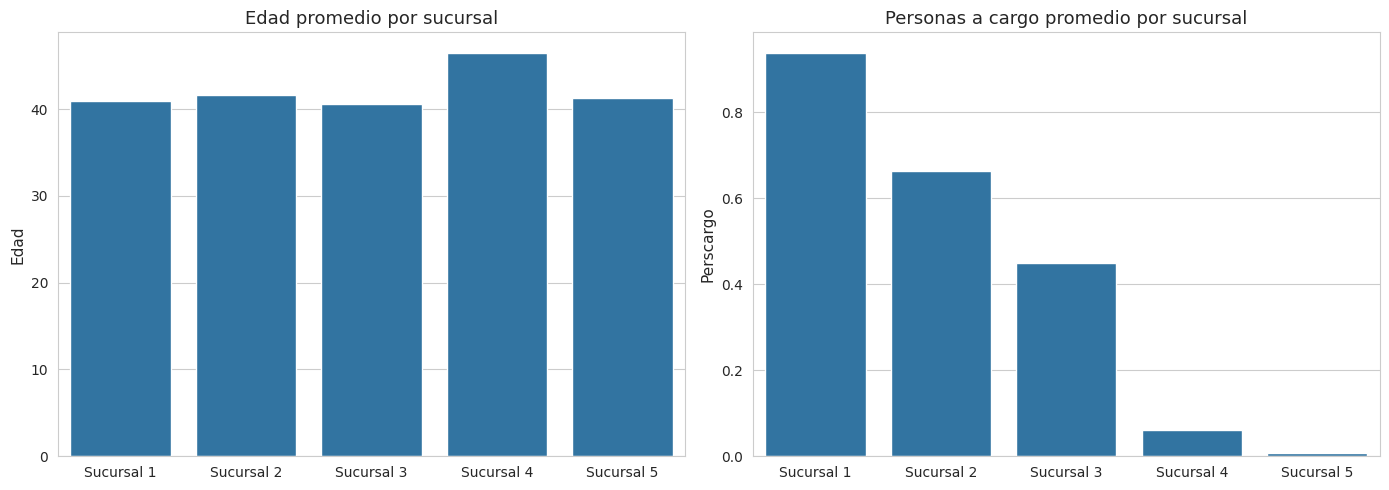

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=df_perfiles.index, y=df_perfiles['Edad'], ax=axes[0])
axes[0].set_title('Edad promedio por sucursal')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

sns.barplot(x=df_perfiles.index, y=df_perfiles['Perscargo'], ax=axes[1])
axes[1].set_title('Personas a cargo promedio por sucursal')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**10. Gráfico de araña para la representación multidimensional**



In [132]:
features = variables
df_prc = pd.DataFrame(PRC, columns=features, index=[f'Sucursal {i+1}' for i in range(5)])

minimos = df_prc.min()
maximos = df_prc.max()

normalizados = []

for i in range(len(df_prc)):
    fila = df_prc.iloc[i]
    fila_norm = {}

    for col in features:
        if maximos[col] == minimos[col]:
            fila_norm[col] = 0
        else:
            fila_norm[col] = (fila[col] - minimos[col]) / (maximos[col] - minimos[col])

    fila_norm['Sucursal'] = df_prc.index[i]
    normalizados.append(fila_norm)

df_norm = pd.DataFrame(normalizados)
display(df_norm.round(3))

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP),Sucursal
0,0.072,1.000,1.000,0.535,0.726,0.700,0.804,0.363,0.961,Sucursal 1
1,0.187,0.000,0.705,0.000,0.039,0.076,0.000,1.000,0.018,Sucursal 2
2,0.000,0.933,0.474,0.218,0.218,0.253,0.232,0.480,0.137,Sucursal 3
3,1.000,0.705,0.057,0.416,0.000,0.000,0.144,0.000,0.000,Sucursal 4
4,0.111,0.013,0.000,1.000,1.000,1.000,1.000,0.275,1.000,Sucursal 5


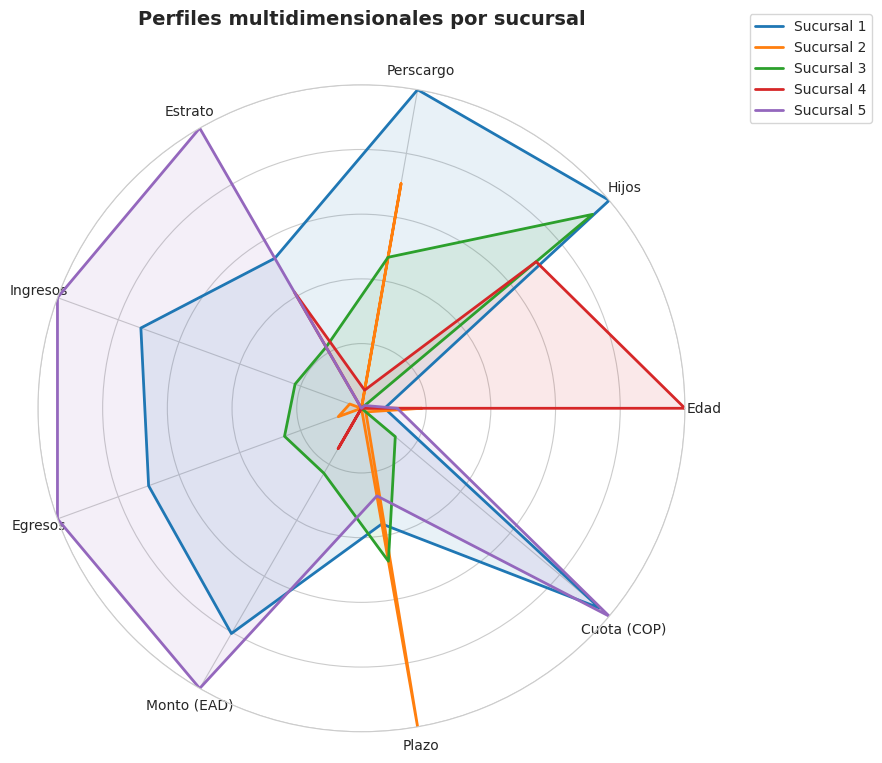

In [133]:
def grafico_radar(df, variables, titulo='Perfiles multidimensionales por sucursal'):
    N = len(variables)
    angulos = [n / float(N) * 2 * np.pi for n in range(N)]
    angulos += angulos[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
    colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, row in df.iterrows():
        valores = row[variables].tolist()
        valores += valores[:1]
        ax.plot(angulos, valores, linewidth=2, label=row['Sucursal'], color=colores[i])
        ax.fill(angulos, valores, alpha=0.10, color=colores[i])

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(variables, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    ax.set_title(titulo, y=1.08, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.30, 1.12))
    plt.tight_layout()
    plt.show()

grafico_radar(df_norm, features)

**Interpretación de los resultados**

- A partir de la integración realizada se observa que los solicitantes no se distribuyen de manera uniforme entre las cinco sucursales, lo cual sugiere que algunos perfiles concentran un mayor volumen de clientes que otros. Esto indica que la reorganización no solo depende de la cantidad de sedes, sino también de la composición interna de cada grupo.

- Las sucursales presentan diferencias visibles en variables como ingresos, egresos, monto y cuota. Esto significa que cada grupo reúne solicitantes con condiciones crediticias particulares, lo cual puede ser útil para diseñar diferentes estrategias de atención, evaluación o acompañamiento comercial.

- El análisis de municipios permite identificar cuáles zonas tienen mayor representación dentro de cada sucursal, lo cual puede servir para decidir ubicaciones o coberturas en el proceso de consolidación de oficinas.

- El porcentaje de preaprobación y prenegación da una lectura adicional sobre el comportamiento de riesgo o viabilidad de los clientes agrupados. Estos indicadores ayudan a reconocer qué sucursales concentran perfiles más favorables o más exigentes desde la perspectiva del crédito.


**Conclusiones**

1. La integración multidimensional permitió reagrupar de manera satisfactoria a los solicitantes en cinco nuevas sucursales.  Esto demuestra que, a partir de variables numéricas del perfil del cliente, es posible construir una organización alternativa de la atención comercial y operativa.

2. Los grupos obtenidos no son homogéneos entre sí, lo cual confirma la existencia de perfiles diferenciados dentro de la base de datos.  Las diferencias observadas en edad, personas a cargo, ingresos, egresos, monto y cuota muestran que cada sucursal representa un segmento particular de solicitantes.

3.  Al revisar los municipios de procedencia, se evidencia que ciertas sucursales concentran con mayor fuerza algunos municipios, lo que puede orientar decisiones sobre cobertura geográfica o ubicación estratégica.

4. El análisis de preaprobación y prenegación complementa la lectura operativa del clustering. No solo interesa saber cuántos clientes quedan en cada grupo, sino también qué tan favorable resulta ese conjunto desde la perspectiva del proceso crediticio.

5. Cada sucursal atiende perfiles de clientes distintos, por lo que es necesario ajustar las estrategias según el tipo de cliente.